# Assignment 2 MOOC

In this exercise we want to conduct parameter inference and uncertainty quantification related to river bed conductance in the transient groundwater flow problem using MODFLOW and DREAM algorithm. 

The groundwater flow equation in general describes the flow of water in a aquifer. The very general formula can be derived using Gauss law: Imagine an aquifer to be a cube where water flows in and out. Gauss law states that the sum of all sources and sinks within a vector field F in the cube has to be equal to the in and outflow. That is $ div(F) = F_{in} - F_{out} $. Gauss theorem is formulated using integrals and the normal derivative to describe in and outflows, however the core idea is the equality described above. Using this idea and intuition and substituting Darcy’s law into the continuity equation for a slightly 
compressible fluid and neglecting spatial density gradients yields the three-dimensional groundwater flow equation:
$$ S_s \frac{\partial h}{\partial t} - \nabla \times (K\nabla h) = q_{in} - q_{out}$$
Here $h(x,t)$ is the hydraulic head , $K$ the hydraulic conductivity, $S_0$ the specific storage, $\nabla \times$ the divergence operator and $q_{in} - q_{out}$ the volumetric source/sink term.

Note that this is a non-linear second order PDE and hence requires a numerical solver. MODFLOW for instance uses finite differences. The concept behind this numerical method is quite straight forward: one dicretizes in space and time, approximates the partial derivatives at those discretized points using finite differnce quotients. This yields a linear system one can solve for. Finally, one can interpolate using the dicretized points. To get unique solutions, one also requires boundary conditions. There are several different forms of the latter, e.g. Dirichlet and Neumann boundary conditions. We will discuss specific boundary conditions in task 2.

Second, this equation depends on the type of the aquifer. That is, if the aquifer is confined or unconfined, if it is isotropic or not, homogeneous or not etc.

Finally, the equation changes if we regard a steady-state or not. "Steady state means that the orders of the quantities like the 
groundwater table elevation are dominantly constant. All computed results are independent of the time; so for a control volume (CV) and a steady state simulation, the fluxes in and out of the CV are the same No mass is added or extracted from the model domain, consequently the source term on the right hand side (RHS) of the flow equation is zero " (Powerpoint MMUQ_Equations_General slide 12). The source term or also transient flow is the $S_s \frac{\partial h}{\partial t}$ term. MODFLOW treats the steady-state equation, which is good in the sense that we lose the temporal derivative.

# Task 1
In the first task we review key aquifer properties. Most of the definition were extracted from Block 0 of MOOC.

An aquifer is an underground layer of water-bearing permeable rock or unconsolidated materials (gravel, sand, silt, or clay) from which groundwater can be usefully extracted using a water well.

1. Unconfined aquifer: It is an aquifer with the water table as its upper
boundary. Because the aquifer is not under pressure the water level in a
well is the same as the water table outside the well.
2. Confined aquifer: It is an aquifer found between two relatively imperme
able layers.

Hydraulic conductivity
-------------
Hydraulic conductivity (K), is a property of vascular plants, soils and rocks,
that describes the ease with which a fluid (usually water) can move through
pore spaces or fractures. It depends on the intrinsic permeability of the ma
terial, the degree of saturation, and on the density and viscosity of the fluid.  It is the propor
tionality constant in Darcy’s law, and hence, as we subistuted Darcy's law to get the groundwater flow equation, plays a major role.

Transmissivity
-------------

Transmissivity (T) is the product of the average hydraulic conductivity (K)
and the saturated thickness of the aquifer (b). 

Porosity
-------------
It is the quotient of the volume of solids and the total volume. From this definition, I would intuitively describe the porosity as the percentage of capacity of the solid to store/get water. It is a totally different concept than permeability.

Specific storage
-------------
Specific storage (SS) of a saturated confined aquifer is the volume of water that
a unit volume of aquifer releases from storage under a unit decline in head.

Specific yield
-------------
It is the volume of the water that an unconfined aquifer releases from storage
per unit surface area of aquifer per unit decline of the water table. It is a result of gravity.

River bed conductance
-------------
This is the parameter of interest. Mathematically, as stated on the exercise sheet can be expressed as:
$$ C_{riv} = \frac{K_{riv} \times w_{riv} \times L_{riv}}{T_{riv}}$$
where $C_{riv}$ is the river bed conductance, $K_{riv}$ is the hydraulic conductivity of the river bed, $w_{riv}$ is the width of the river, $L_{riv}$ is the length of the river within a cell and $T_{riv}$ is the thickness of the riverbed. From this ratio, one could state that CRIV controls the rate of exchange between river water and groundwater. That is, it states if the river bed for instant acts as a barrier or if river and aquifer are well connected in the sense that water can move in both directions.

# Task 2

In this task we are asked to specify the uniform prior using the log-scale. This is done by using spotpy and the code provided by spot_setup_modflow:



In [ ]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import os

import numpy as np
import pandas as pd
import spotpy
from spotpy.parameter import Uniform

from additional_functions import load_modflow_model, load_heads, get_head_ts, HiddenPrints, process_model_path


class spot_setup(object):

    def __init__(self, _used_algorithm):
        self._used_algorithm = _used_algorithm
        # !!! Specify the prior !!!!!
        # def Uniform(low, high):
        #     return spotpy.parameter.Uniform(low=np.log10(low), high=np.log10(high))
        # This setup expects the parameters to be uniform distributed in [log10(min), log10(max)]
        # on a logarithmic scale.
        # the 10^x is done in simulation
        self.params = [Uniform(low=-5, high=-1),
                       Uniform(low=-5, high=-1),
                       Uniform(low=-7, high=-2),
                       Uniform(low=-7, high=-2),
                       Uniform(low=-7, high=-2)]


    def parameters(self):
        return spotpy.parameter.generate(self.params)

    @staticmethod
    def simulation(x):
        # with HiddenPrints():
        model_name = "flood.nam"
        model_path = "flood_riv_dream" #os.path.join("..", "flood_riv_dream")
        ml = load_modflow_model(model_name, model_path)
        cond_mask = np.load('mask_new.npy')  # load a mask that defines where are cond_1,_2,_3,_4,_5
        cond_mask[cond_mask == 1] = 10 ** (x[0])  # where the mask equals 1 -> parameter 1
        cond_mask[cond_mask == 2] = 10 ** (x[1])  # where the mask equals 2 -> parameter 2
        cond_mask[cond_mask == 3] = 10 ** (x[2])  # where the mask equals 3 -> parameter 3
        cond_mask[cond_mask == 4] = 10 ** (x[3])  # where the mask equals 4 -> parameter 4
        cond_mask[cond_mask == 5] = 10 ** (x[4])  # where the mask equals 5 -> parameter 5
    
    #......

# Task 3 and 4

In this task we let the model run to conduct uncertainty quantification and parameter inference. Let's discuss the code, the algorithm and briefly the maths behind it. Our overall aim is to estimate a posterior distribution and to sample from it. The posterior distribution describes the effect of the parameters on the outcome. To draw samples, we use MCMC. The concept is to find a Markov Chain that converges to a stationary distribution, which again approximates our posterior distribution using Bayes' theorem. In Block 1 we discussed the RWMA algorithm in detail as an easy MCMC algorithm. The major shortcoming of the RWMA was that we assumed the proposal distribution to be symmetric. In Block 2 we got introduced to the Metropolis-Hasting Algorithm which allows arbitrary proposal distributions. It basically works like the RWMA, only the acceptance probability is different and adapted according to the fact that the proposal distribution can also be asymmetric. 

Next, DREAM as described in the reference "Vrugt, J.A., Vrugt, J. A. (2016). Markov chain Monte Carlo simulation using the DREAM
software package: Theory, concepts, and MATLAB implementation. Environmental Mod
elling Software, 75, 273-316." goes a step further and uses the benefits of Differential Evolution. It uses several different Markov Chains following the target distribution but then performs crossover between the different chains to get the new candidate. Then, as before the acceptance probability is computed and the update performed depending on that probbaility. To be precise, this ansatz of using several Markov Chains is the DifferentialEvolutionMarkovChain (DE-MC) algorithm, but "the DREAM algorithm has it roots within DE-MC but uses subspace sampling and outlier chain correction to speed up convergence to the target distribution. Subspace sampling is implemented in DREAM by only updating randomly selected dimensions of x each time a proposal is generated." (Vrugt et al.) The update is then
$$
dX_A^i
=
\zeta_d^i
+
\left( 1_d^i + \lambda_d^i \right)
\gamma(\delta_d^i)
\sum_{j=1}^{\delta}
\left( X_A^{a_j} - X_A^{b_j} \right) \text{(Vrugt et al.)}
$$ 
Using this update, the new candidate is build (old value + update + noise), its acceptance probability is computed and then the new parameter is computed depending on acceptance or rejectance. This is all done within the predefined function "spotpy.algorithms.dream". The call "sampler.sample" then starts the sampling.

We used here 400 repitions and 7 Markov Chains.

In [ ]:
'''
Code implemented after an example from Tobias Houska (2018), 
part of Statistical Parameter Estimation Tool (SPOTPY).
:author: Alexandra Geist, modified by Tanu Singh
This example implements the python version of MODFLOW into SPOTPY.
'''

import spotpy
import numpy as np
from spot_setup_modflow import spot_setup
import random
from mpi4py import MPI
from additional_functions import process_model_path
import pickle as pkl

if __name__ == "__main__":
    # parallel = 'seq'

    # to run the DREAM in parallel using mpi, start this script from the
    # commandline with
    # $ mpiexec -n 12 python run_dream.py
    # with as many cores you want to use.
    # If you have enabled hyper-threading you can use the option --use-hwthread-cpus
    # to start 2 processes on every physical core.
    parallel = 'mpi'

    import os
    model_name = "flood.nam"
    model_path = "flood_riv_dream" 

    # make separated modflow working dir for every process.
    comm = MPI.COMM_WORLD
    if not os.path.exists(process_model_path(model_path)):
        from distutils.dir_util import copy_tree
        # copy flood dir data to process dir
        fromDirectory = model_path
        toDirectory = process_model_path(model_path)
        copy_tree(fromDirectory, toDirectory)

    print("run_dream with parallel=" + parallel)
    spot_setup = spot_setup(_used_algorithm='dream')
    # !!! Specify the information !!!!!
    # Select number of maximum repetitions
    rep = 20 * 20  # ?

    # Select number of chains and set the Gelman-Rubin convergence limit
    nChains = 7  # ?
    convergence_limit = 1.2
    runs_after_convergence = 2000

    # Set the random state. Additionally random state is set in spotpy.parameter.Uniform !
    random_state = 5
    # random_state = None
    if random_state is None:
        random_state = np.random.randint(low=0, high=2 ** 30)
    np.random.seed(random_state)
    random.seed(random_state)

    sampler = spotpy.algorithms.dream(spot_setup, dbname='DREAM_modflow', dbformat='csv', db_precision=np.float32,
                                      save_sim=True, random_state=random_state, parallel=parallel)

    r_hat = sampler.sample(rep, nChains=nChains, convergence_limit=convergence_limit,
                           runs_after_convergence=runs_after_convergence)

    # save r_hat with pickle
    with open('r_hat.pkl', 'wb') as f:
        pkl.dump(r_hat, f, pkl.HIGHEST_PROTOCOL)

    results = sampler.getdata()  # Load the likelihood, and the parameter values of all simulations


We ran the code overnight and will now discuss the obtained plots. 

We will discuss two type of plots. First, note that the unknown parameter we want to estimate using the Bayesian Ansatz is the river bed conductance (CRIV).  To account for spatial variability
in CRIV, the channel is divided into two sections with different values for CRIV and the river
into three sections. This leads to five different values for CRIV. We have different prior distributions of the respective parameters:

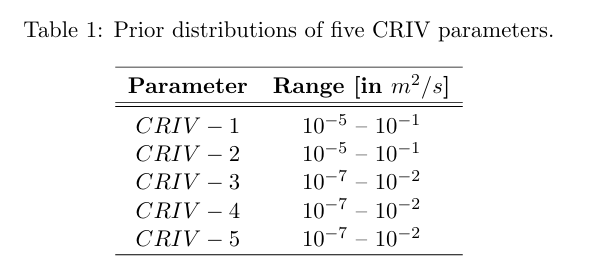

In accordance with the different parameters sections, we observe hydraulic heads at different points within our catchment:

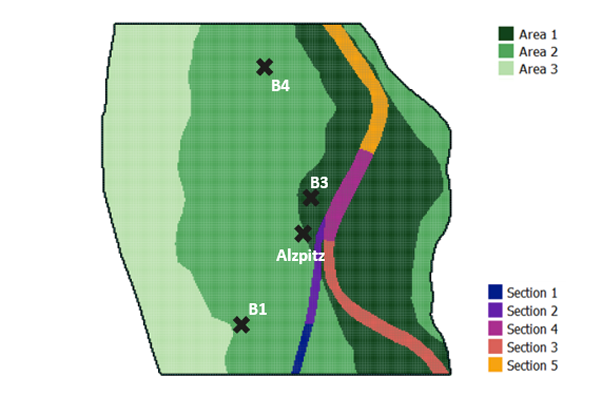

The first analysis consists of looking at the observed hydraulic heads versus our simulated ones. The light blue band represents the uncertainty range (mean ± standard deviation) of simulated groundwater heads across your posterior parameter distribution from the DREAM algorithm sampling. The red dots the actual data.
Generally those plots can be used to evaluate model fit quality. The model depend on the Bayesian inference with the respective priors as explained above. They indicate how well your calibrated model predicts observed groundwater heads. Where the red dots lie within or near the blue uncertainty band, your model is performing well. Moreover, the width of the blue band indicates the uncertainty in your parameter estimates. A wider band suggests greater uncertainty in the CRIV values; a narrower band indicates better constrained parameters.

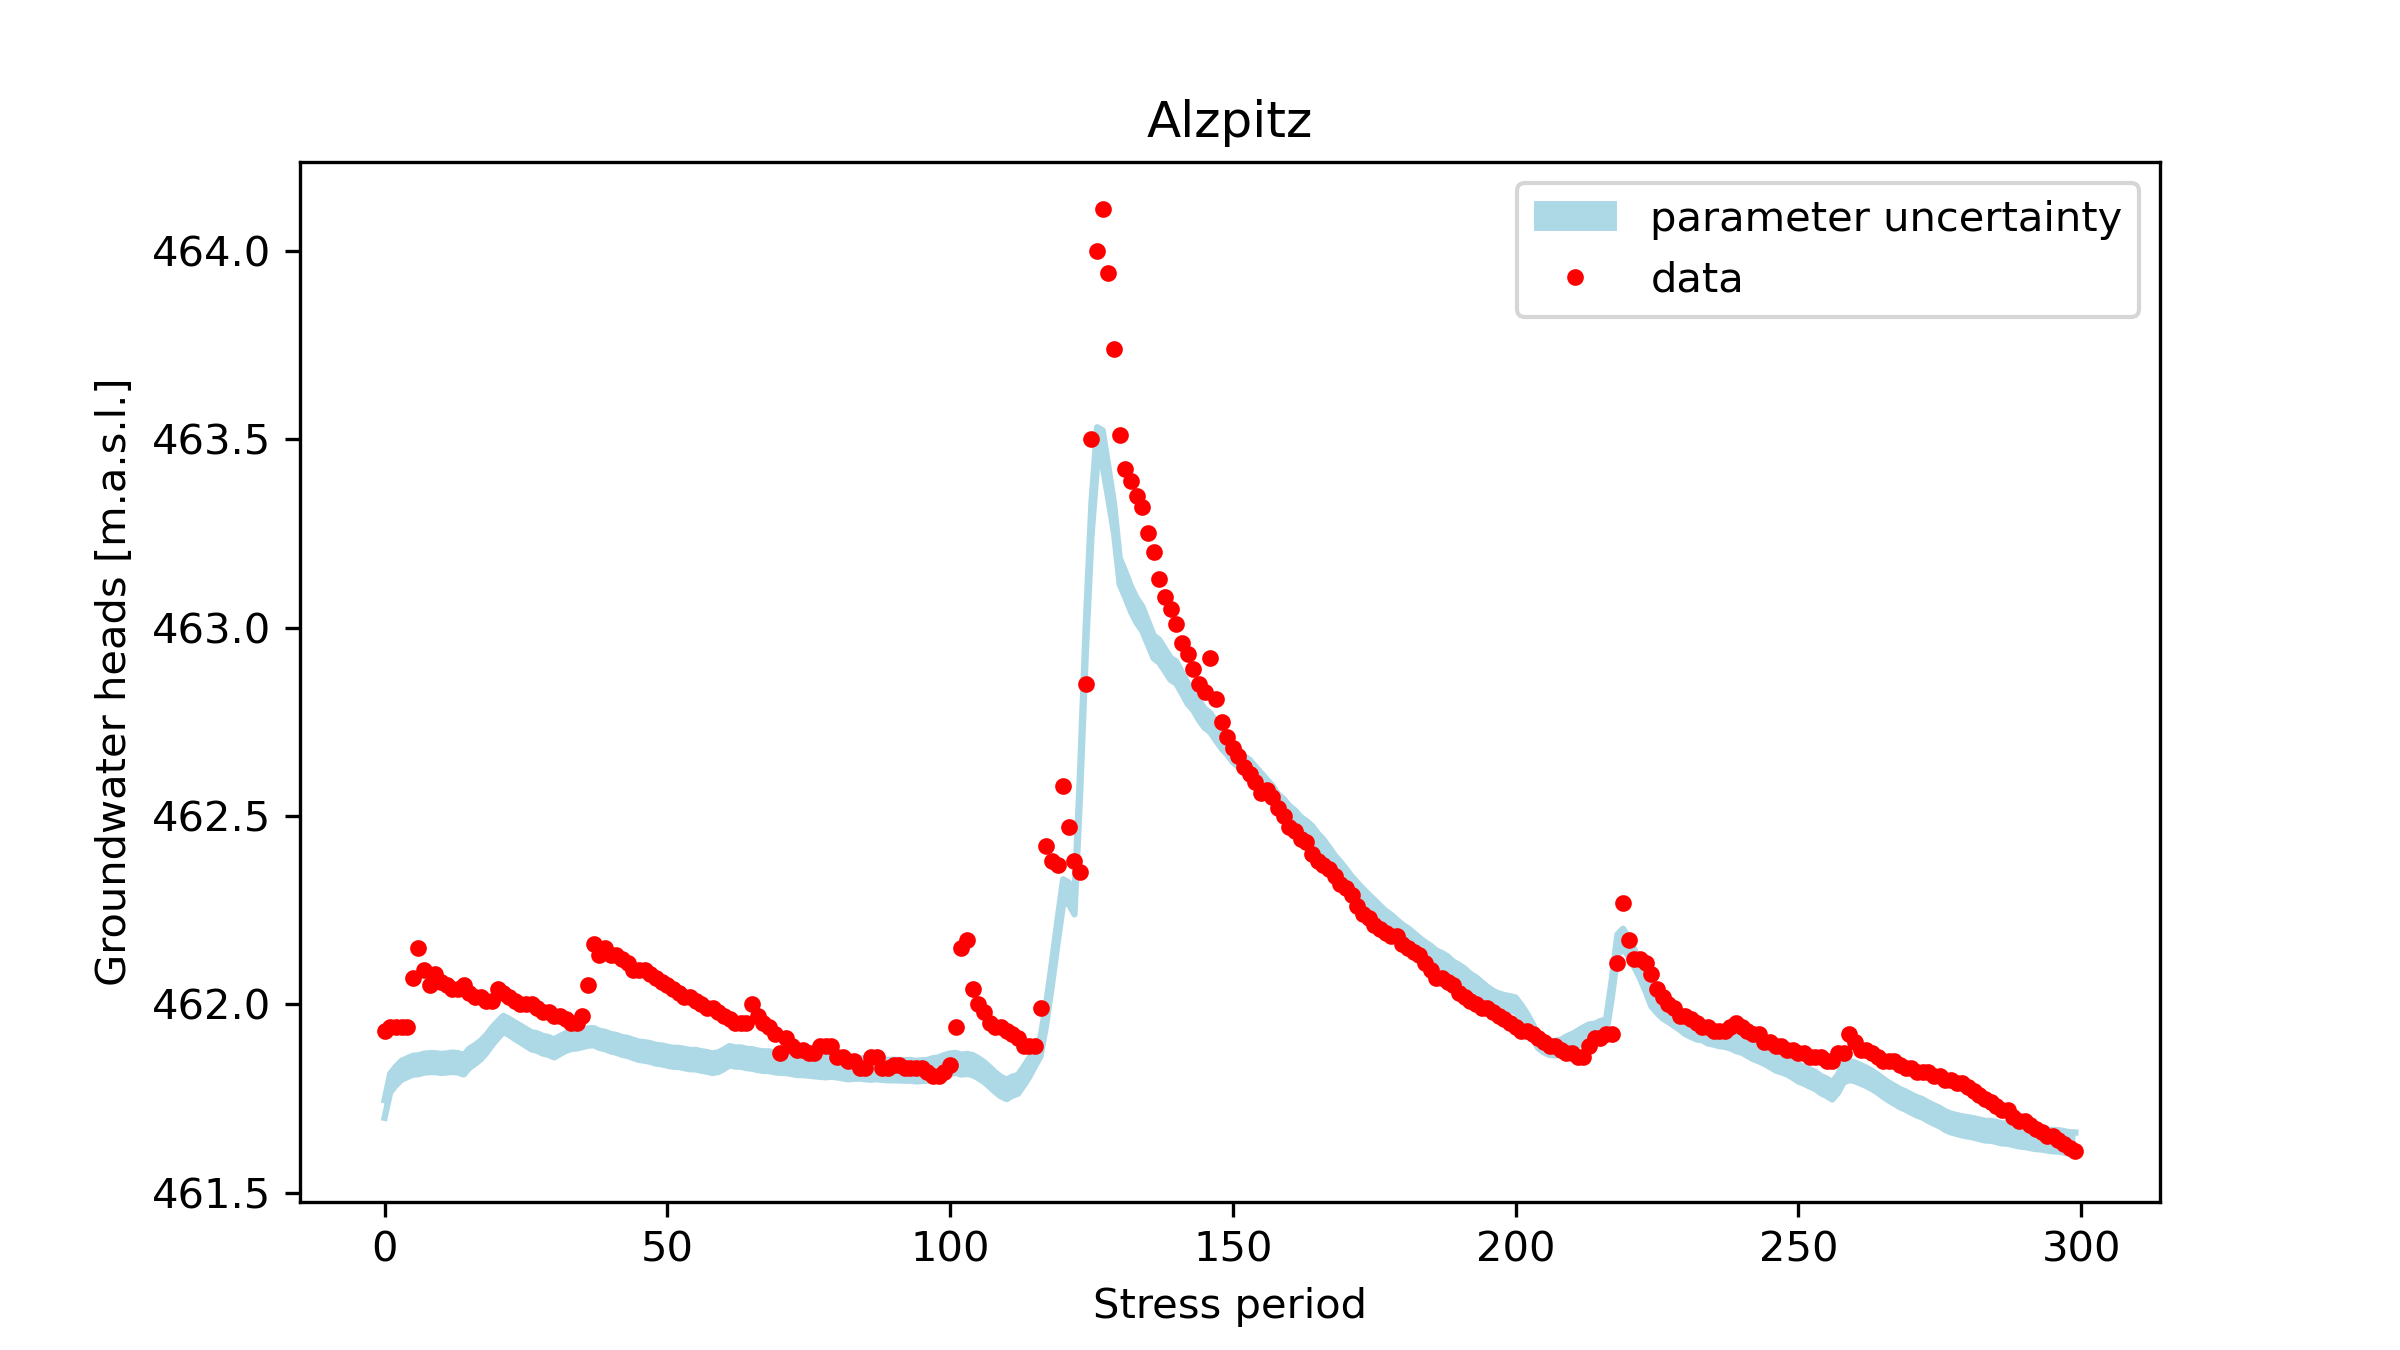

Looking at this we see that we generally underestimate the groundwater heads. Our explaination for this is that looking at the map, Alzpitz is located close to 3 sections where two different flows come together (observed data higher). We did not account well for this yet.

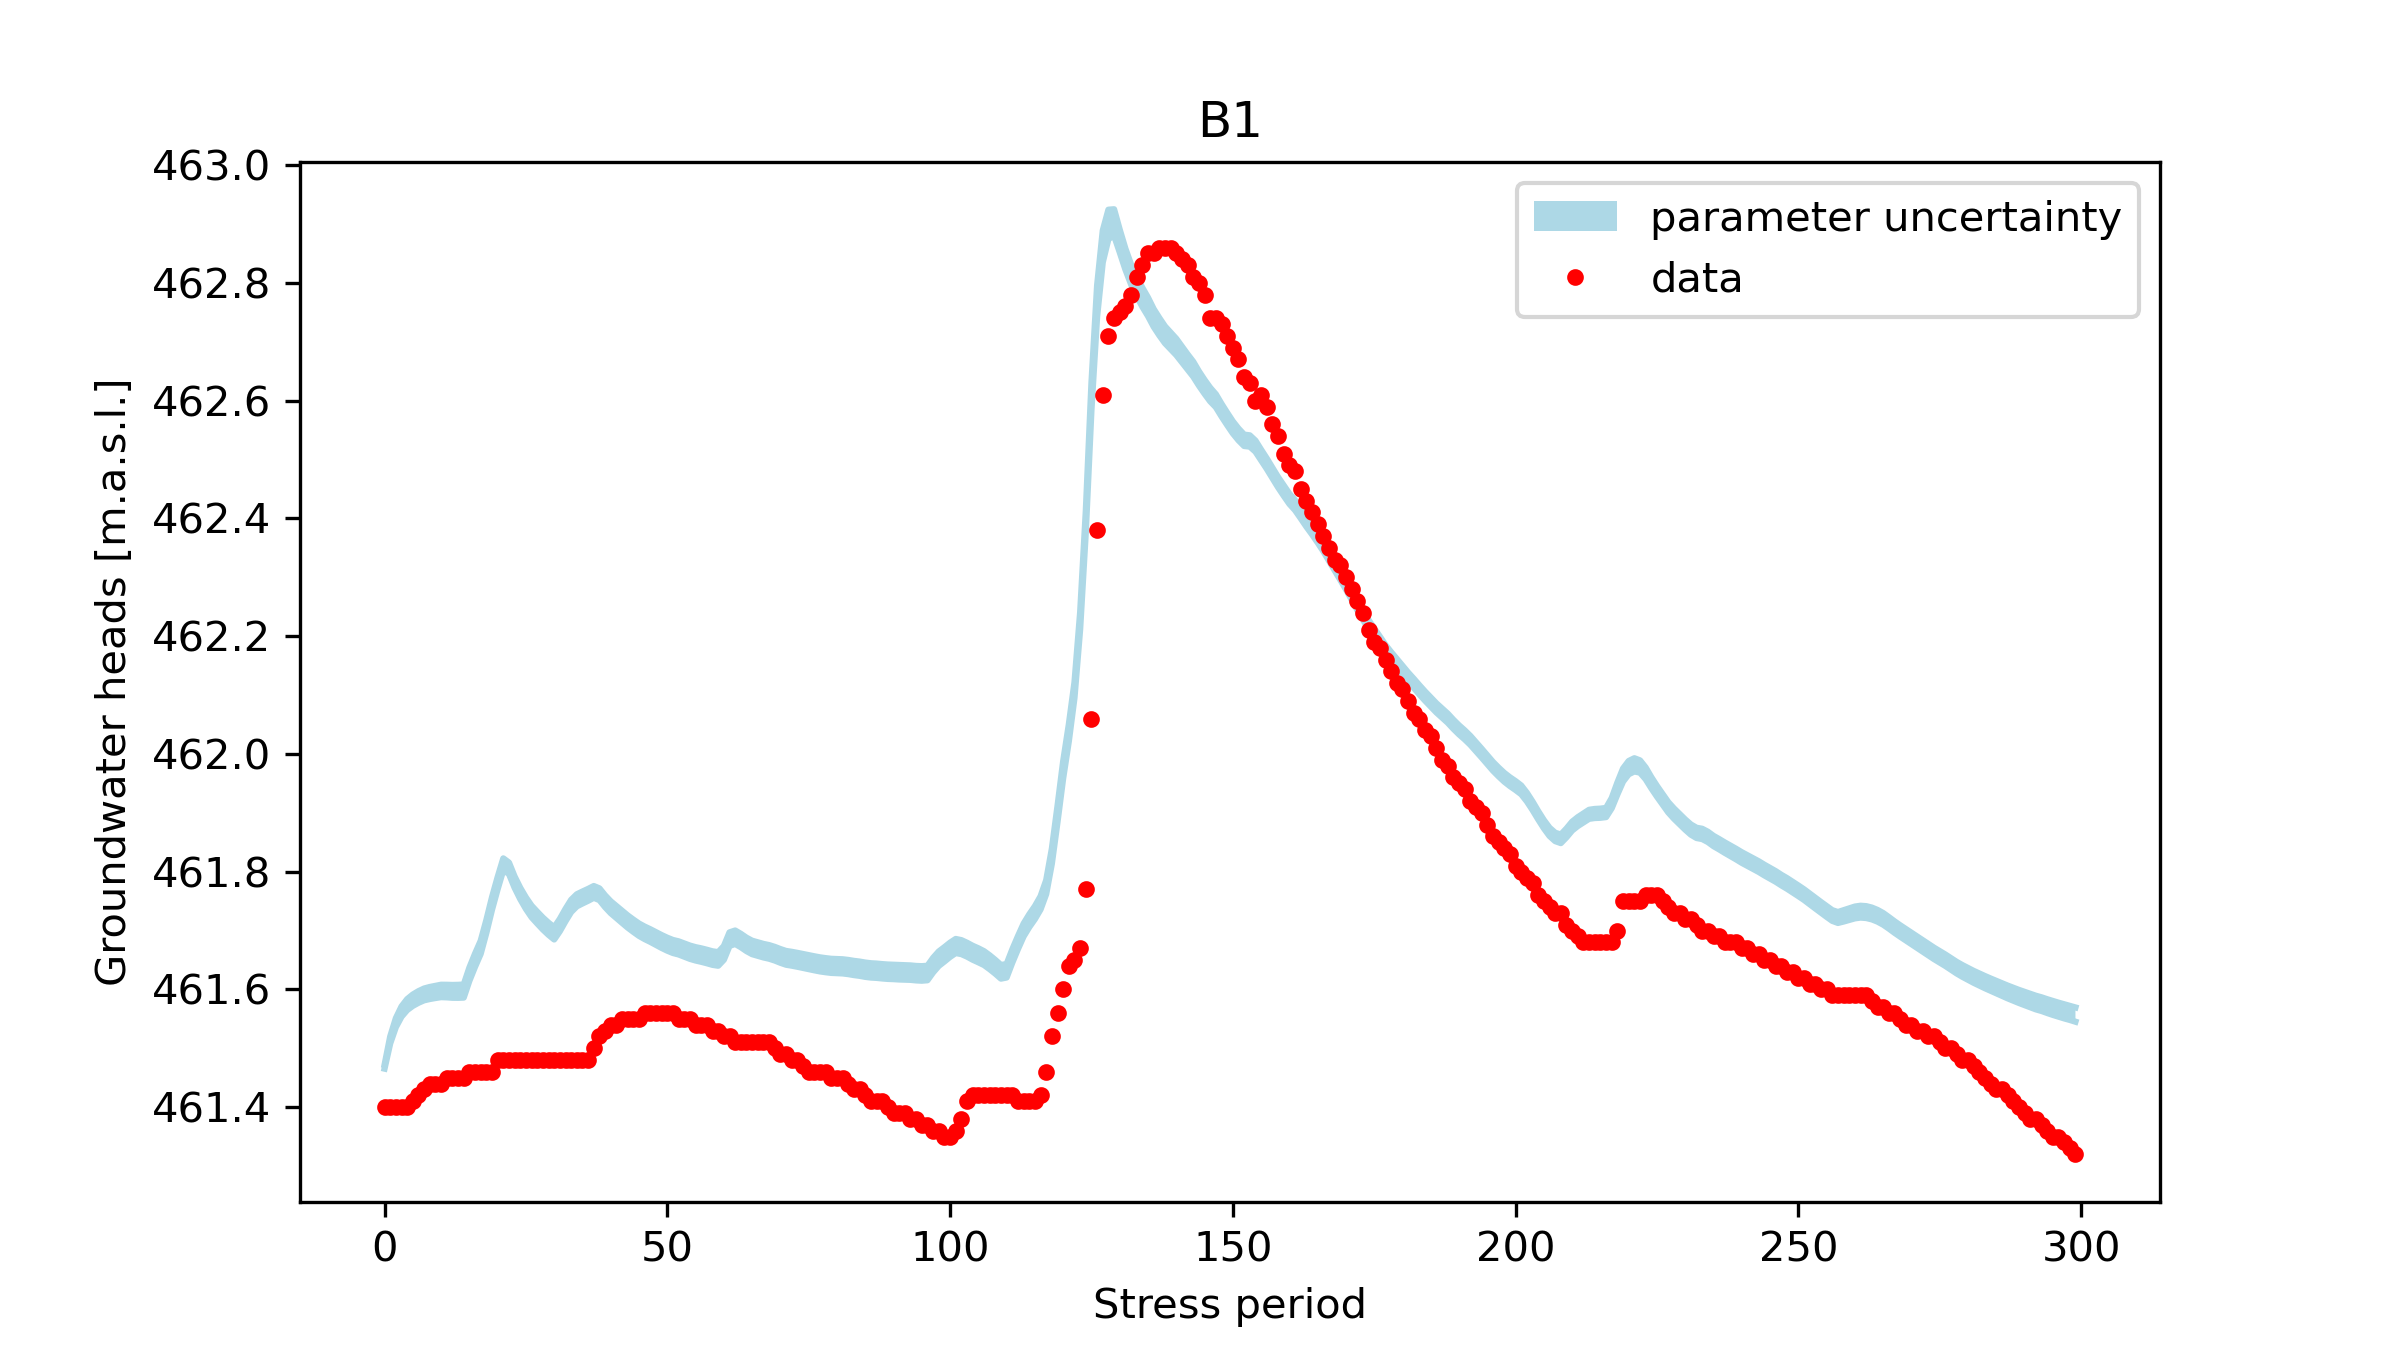

Here we generally overestimate the true heads. B1 is located in area 2 and is mainly driven by parameter 1 and 2.

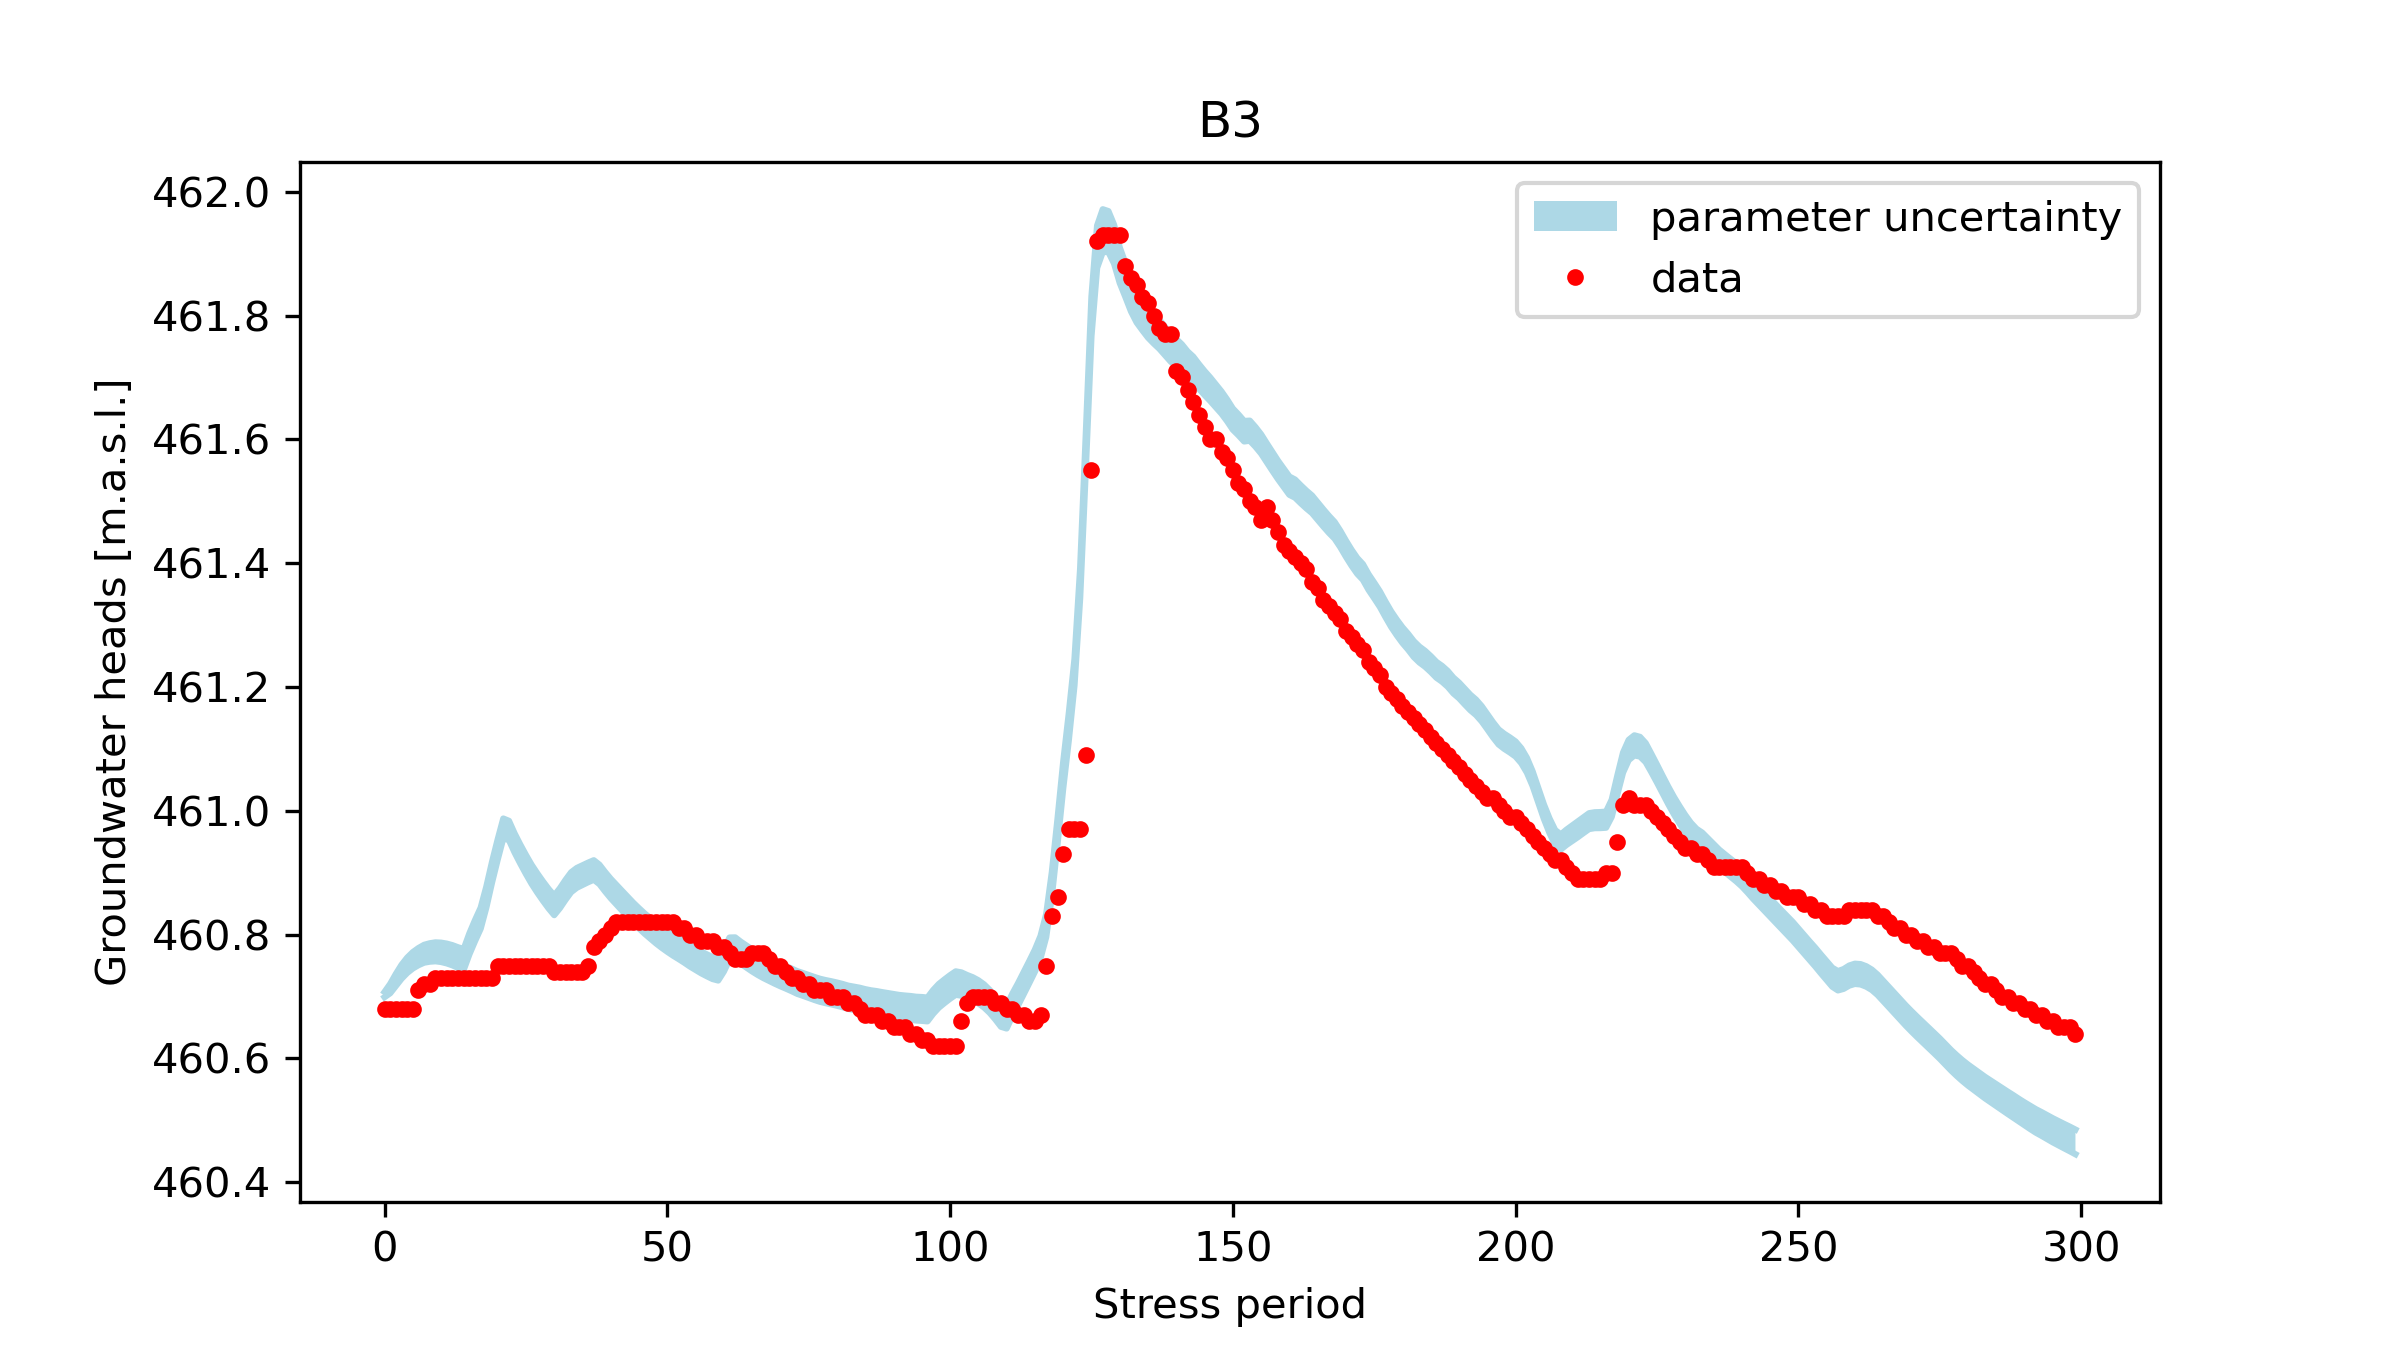

Close to Alpitz head, the model fits better.It in mainly driven by Bayesian inference number 4 and shows the best fit among all


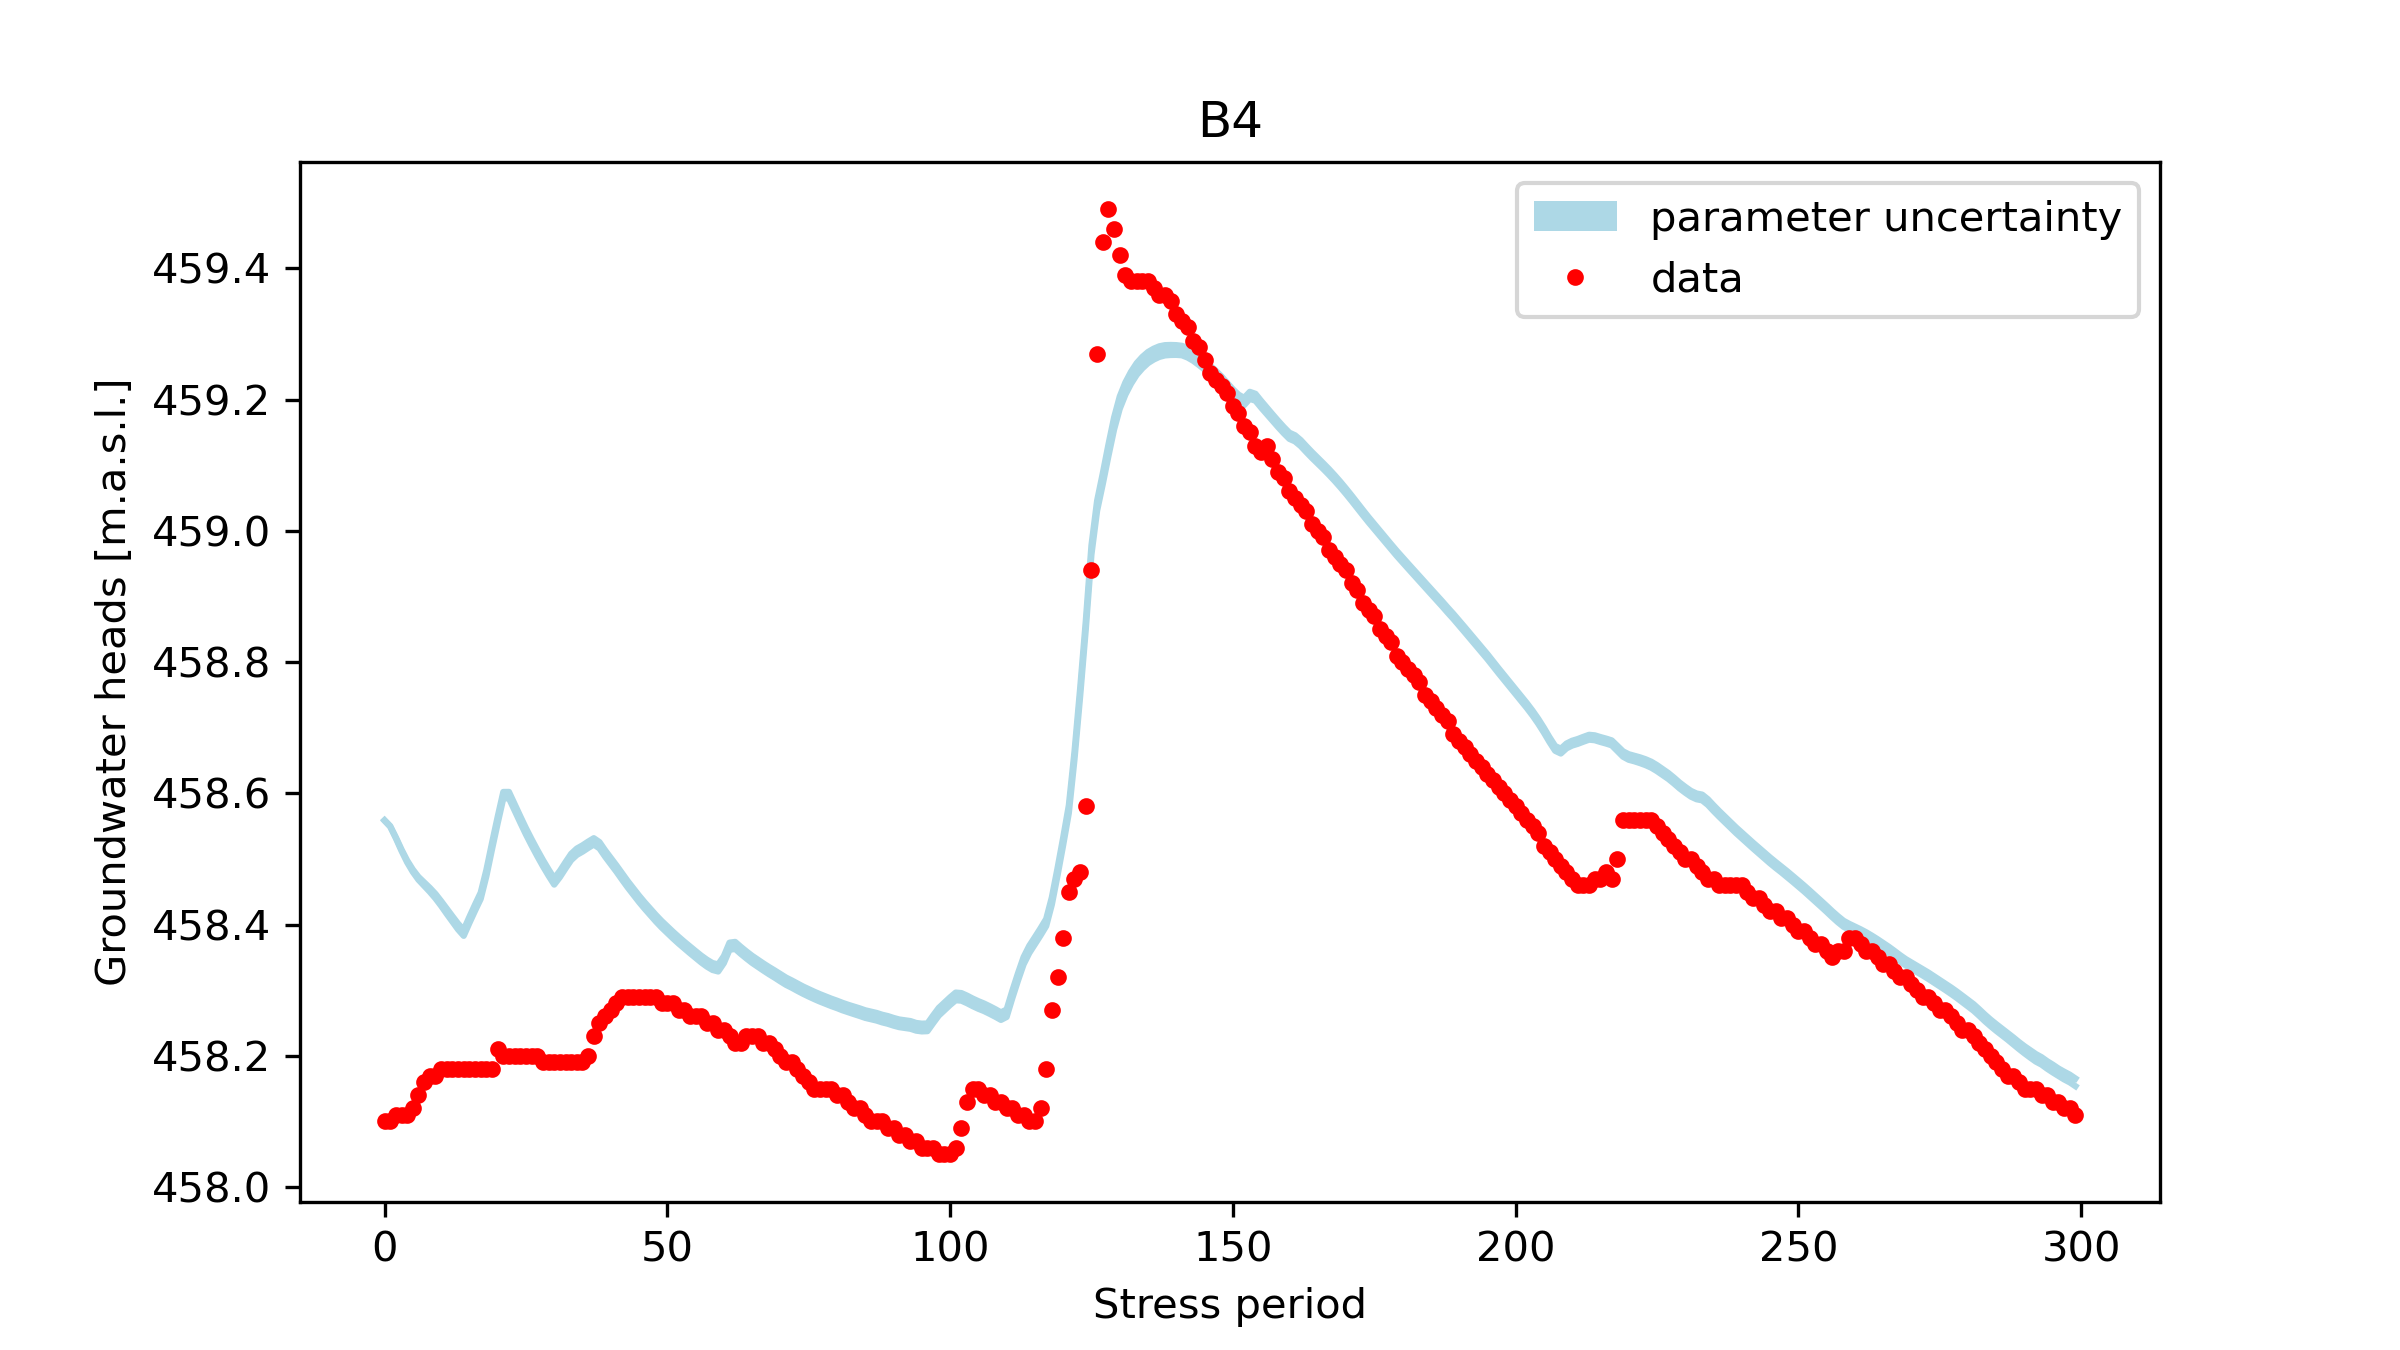
Also located in area 2, we overestimate again the true data.

To conclude, the plots clearly demonstrate that the model performs differently across different monitoring points, revealing spatial variability in model accuracy. Section 4 seems to have the best fit. The plots are a typical output from a Bayesian inverse problem where you're quantifying both parameter uncertainty and predictive uncertainty.

Next, we are looking at the posterior probability distributions of CRIV_1 to CRIV_5 as well as the parameter traces, which show the MC samples for each CRIV parameters across all iterations.

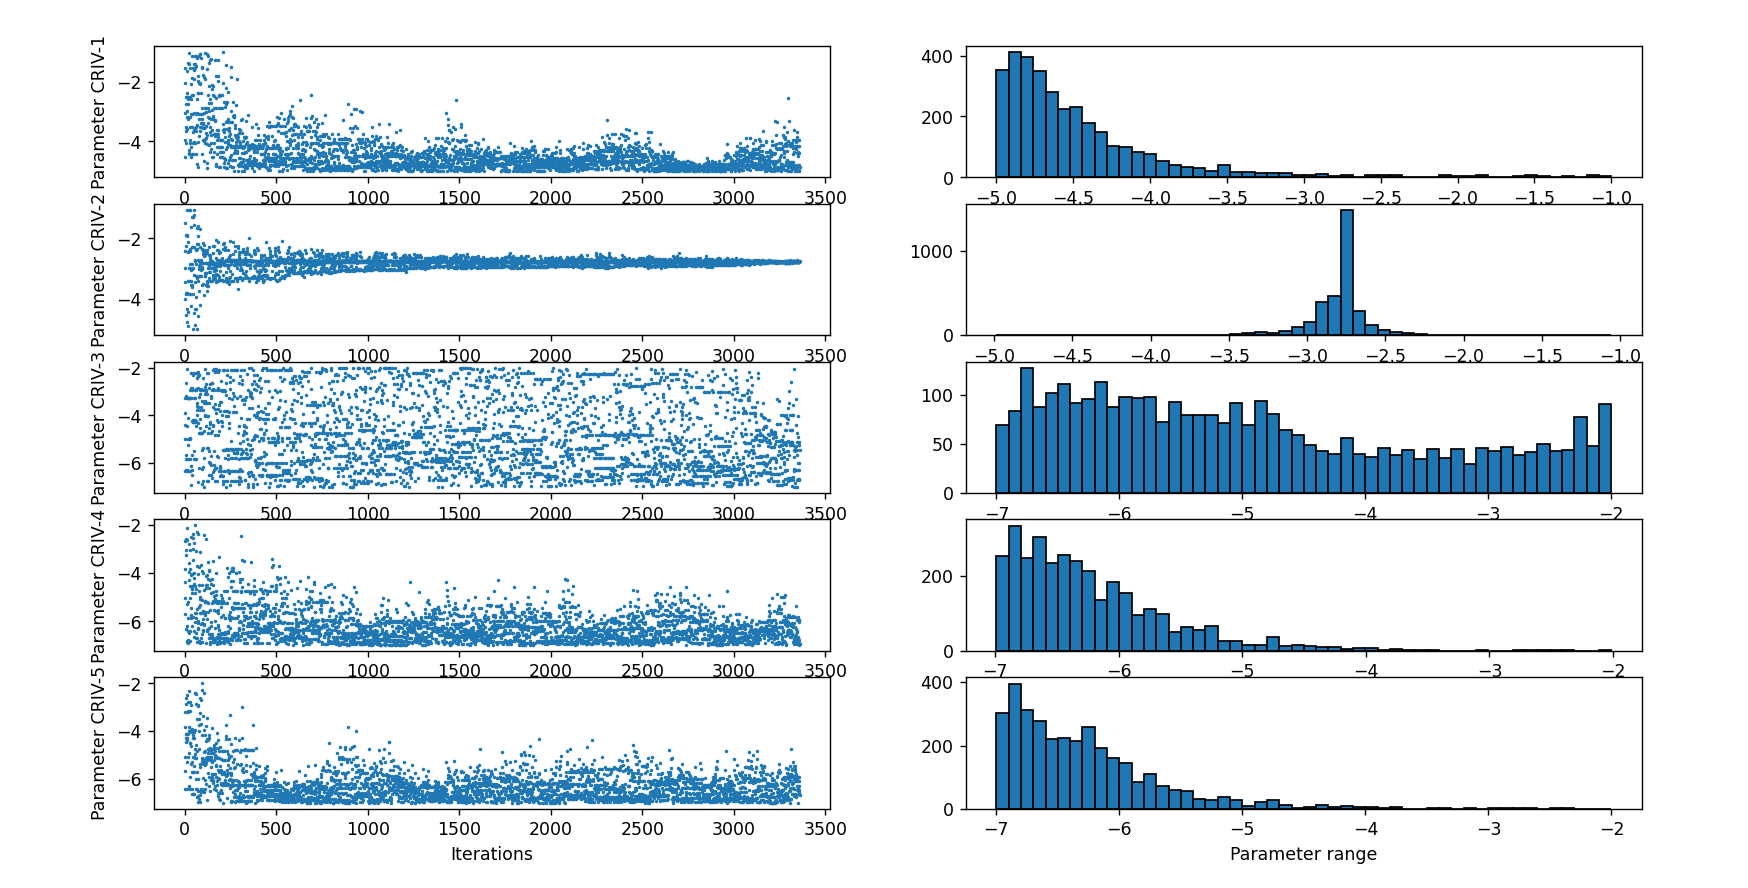

Let's first look at the trace plots and try to understand them. Generally, a Random scatter throughout the iteration range indicates good mixing and convergence to the stationary distribution. On the other hand, if traces show systematic patterns or trends, the chains may not have fully converged. If a trace plot is very narrow, it indicates the data highly constrains that parameter, providing a very "certain" estimate. If the trace jumps between two distinct levels, it suggests the model identifies two different likely values for that parameter, which could indicate a non-unique solution or complex physical interactions. This was fortunately not observed. 

All parameters except 2 show a quite random pattern, implying a descent convergence to a stationary distribution. The parameters are not too constrained.

Looking at the posterior distribution histogramms, one could say that generally our prior beliefs of a uniform distributions are updated, except for Parameter 3. Parameter 1,4 and 5 show quite a similar posterior distribution. Parameter 3 shows a quasi uniform distribution. Finally, the posterior of parameter 2 looks like a peaky and narrow Gaussian, implying a constrained parameter with a wrong prior belief , which is in accordance with the trace plots.

# Task 5

Based on the groundwater heads plots, one would expect that the parameter of section 4 is the most sensitive based on the best fit. Moreover, there are two monitoring points. Based on the trace and posterior distribution plots, one could state that parameter 2 is the most sensitive, as dicussed above. One could also argue that section 2 can be monitored by almost 3 points.

The least sensitive, also based on the broad and flat prior and the scatter across the whole prior range, is parameter 3. The channel section may not have direct monitoring points, making it harder to constrain.

All in all, parameters controlling river-aquifer exchange in well-monitored areas are identifiable; those in poorly monitored sections remain uncertain.

Such studies enable predictive uncertainty quantification for water management, identify which parameters require additional monitoring, guide contamination risk assessment, and inform robust infrastructure design. High flow events enhance river-aquifer recharge, magnifying CRIV sensitivity as seen in the model missfits in the middle of stress period. On the other hand, droughts reverse gradients and constrain different parameters. We can also imagine that seasonal variations compound parameter non-stationarity as those events make it hard to predict consistently.

This study shows that Bayesian inference calculates both the parameter values and how much we can trust them. In the model, the wide range of uncertainty across the five CRIV parameters shows that the river system is not the same everywhere. Some locations are much harder to predict than others. For better groundwater management, decisions should account for these risks. Future data collection should focus on the areas that are most important but currently have the highest uncertainty.